# Interactive seismogram picker (ipympl)

Cursor shows time/amplitude, bandpass filter is applied live, and left-click drops a phase pick.

**Dependencies on the kernel:** `obspy`, `ipympl`, `ipywidgets`. In modern JupyterLab (3/4) `ipympl` ships its lab extension prebuilt, so `pip install ipympl` (or conda) into the shared image is enough.

> The `%matplotlib widget` magic must run *before* the figure is created.

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ipywidgets as widgets
from IPython.display import display
from obspy import UTCDateTime
from obspy.core.event import Pick, WaveformStreamID

In [2]:
# --- get a trace to play with -------------------------------------------
# Swap this for your own read: st = read("mydata.mseed")
try:
    from obspy.clients.fdsn import Client
    t0 = UTCDateTime("2010-02-27T06:34:00")
    st = Client("IRIS").get_waveforms("IU", "ANMO", "00", "BHZ", t0, t0 + 600)
except Exception as e:
    print("FDSN fetch failed, using synthetic:", e)
    from obspy import Trace, Stream
    sr, n = 20.0, 12000
    data = np.random.default_rng(0).normal(0, 1, n).cumsum()
    tr = Trace(data=data.astype(np.float32))
    tr.stats.sampling_rate = sr
    tr.stats.network, tr.stats.station, tr.stats.channel = "XX", "TEST", "BHZ"
    st = Stream([tr])

st.merge(fill_value=0)
trace = st[0]
print(trace)

/srv/conda/envs/notebook/lib/python3.12/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


IU.ANMO.00.BHZ | 2010-02-27T06:34:00.019538Z - 2010-02-27T06:43:59.969538Z | 20.0 Hz, 12000 samples


In [3]:
class SeismogramPicker:
    PHASE_COLORS = {"P": "tab:red", "S": "tab:blue", "other": "tab:green"}

    def __init__(self, trace, figsize=(10, 4)):
        self.raw = trace.copy()       # pristine source, never filtered
        self.picks = []               # [{phase, time(UTCDateTime), line, txt}]

        f_ny = 0.5 * self.raw.stats.sampling_rate

        # --- controls ----------------------------------------------------
        self.bp_on = widgets.Checkbox(value=False, description="bandpass")
        self.bp = widgets.FloatRangeSlider(
            value=[max(0.02, 0.02 * f_ny), 0.4 * f_ny],
            min=0.001, max=f_ny, step=0.01, description="freq (Hz)",
            continuous_update=False, readout_format=".3f",
            layout=widgets.Layout(width="60%"))
        self.corners = widgets.IntSlider(value=4, min=1, max=8, description="corners")
        self.zerophase = widgets.Checkbox(value=True, description="zero-phase")
        self.phase = widgets.Dropdown(options=["P", "S", "other"], value="P",
                                      description="phase")
        self.clear_btn = widgets.Button(description="clear picks", icon="trash")
        self.readout = widgets.HTML("<i>move cursor over the trace…</i>")

        for w in (self.bp_on, self.bp, self.corners, self.zerophase):
            w.observe(self._on_filter_change, names="value")
        self.clear_btn.on_click(self._on_clear)

        # --- figure ------------------------------------------------------
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.fig.canvas.header_visible = False
        self.fig.canvas.toolbar_position = "right"

        self.t = self.raw.times("matplotlib")
        (self.line,) = self.ax.plot(self.t, self.raw.data, lw=0.7, color="k")
        self.vcursor = self.ax.axvline(self.t[0], color="0.6", lw=0.6, alpha=0.0)
        self.ax.xaxis_date()
        self.ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
        self.ax.set_title(self.raw.id)
        self.ax.set_ylabel("counts")
        self.fig.autofmt_xdate()

        self.fig.canvas.mpl_connect("motion_notify_event", self._on_move)
        self.fig.canvas.mpl_connect("button_press_event", self._on_click)

        controls = widgets.VBox([
            widgets.HBox([self.bp_on, self.zerophase, self.corners]),
            self.bp,
            widgets.HBox([self.phase, self.clear_btn]),
            self.readout,
        ])
        self.ui = widgets.VBox([controls, self.fig.canvas])

    # ---- filtering ------------------------------------------------------
    def _apply_filter(self):
        tr = self.raw.copy()
        tr.detrend("demean")
        if self.bp_on.value:
            fmin, fmax = self.bp.value
            tr.filter("bandpass", freqmin=fmin, freqmax=fmax,
                      corners=self.corners.value, zerophase=self.zerophase.value)
        self.line.set_ydata(tr.data)
        self.ax.relim(); self.ax.autoscale_view(scalex=False)
        self.fig.canvas.draw_idle()

    def _on_filter_change(self, _):
        self._apply_filter()

    # ---- cursor ---------------------------------------------------------
    def _on_move(self, event):
        if event.inaxes is not self.ax or event.xdata is None:
            return
        t = UTCDateTime(mdates.num2date(event.xdata))
        self.vcursor.set_xdata([event.xdata, event.xdata])
        self.vcursor.set_alpha(0.7)
        self.readout.value = (
            f"<b>t</b> = {t.isoformat()} &nbsp;|&nbsp; "
            f"<b>offset</b> = {t - self.raw.stats.starttime:+.3f}s &nbsp;|&nbsp; "
            f"<b>amp</b> = {event.ydata:.1f}")
        self.fig.canvas.draw_idle()

    # ---- picking --------------------------------------------------------
    def _on_click(self, event):
        if event.inaxes is not self.ax or event.button != 1 or event.xdata is None:
            return
        # ignore clicks while pan/zoom is active
        tb = self.fig.canvas.toolbar
        if tb is not None and getattr(tb, "mode", ""):
            return
        ph = self.phase.value
        t = UTCDateTime(mdates.num2date(event.xdata))
        line = self.ax.axvline(event.xdata, color=self.PHASE_COLORS[ph], lw=1.2)
        txt = self.ax.annotate(
            ph, xy=(event.xdata, 1), xycoords=("data", "axes fraction"),
            xytext=(2, -2), textcoords="offset points",
            color=self.PHASE_COLORS[ph], fontsize=9, va="top")
        self.picks.append({"phase": ph, "time": t, "line": line, "txt": txt})
        self.fig.canvas.draw_idle()

    def _on_clear(self, _):
        for p in self.picks:
            p["line"].remove(); p["txt"].remove()
        self.picks.clear()
        self.fig.canvas.draw_idle()

    # ---- export ---------------------------------------------------------
    def to_obspy_picks(self):
        wid = WaveformStreamID(seed_string=self.raw.id)
        return [Pick(time=p["time"], phase_hint=p["phase"], waveform_id=wid)
                for p in sorted(self.picks, key=lambda d: d["time"])]

    def _ipython_display_(self):
        display(self.ui)

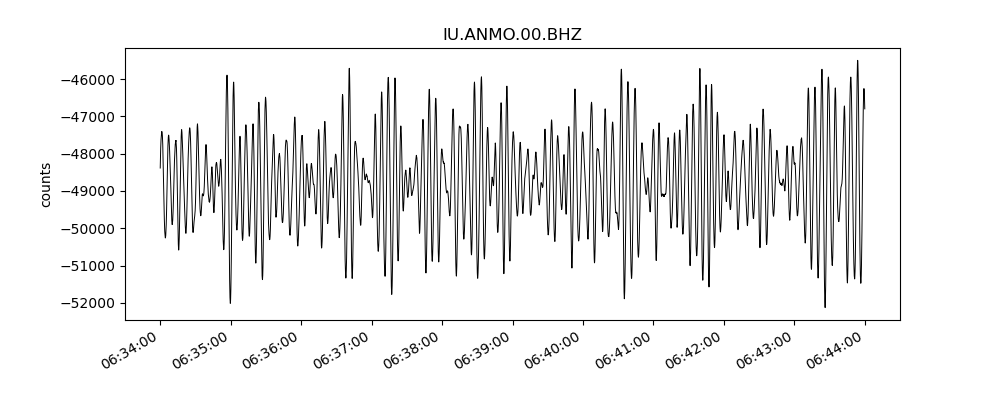

In [4]:
picker = SeismogramPicker(trace)
picker

In [5]:
# after picking, pull them out as ObsPy Pick objects (sorted by time)
for p in picker.to_obspy_picks():
    print(p.phase_hint, p.time, p.waveform_id.id)

# -> drop into a Catalog/Event and write QuakeML if you want:
# from obspy.core.event import Catalog, Event
# Catalog([Event(picks=picker.to_obspy_picks())]).write("picks.xml", format="QUAKEML")